In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

In [2]:
dataset_path = Path('Datasets')
title = 'El conde de Montecristo - Alexandre Dumas'

if not Path(dataset_path / f'{title}.txt').exists():
    epub_file = dataset_path / 'raw' / f'{title}.epub'
    txt_file = dataset_path / f'{title}.txt'
    !ebook-convert "{epub_file}" "{txt_file}"

In [3]:
with open(dataset_path / f'{title}.txt', 'r') as f:
    doc = list(map(lambda x: x.lower(), f.read().split()))

print('length of document:', len(doc))
print('first 10 elements :', doc[:10])
print('last 10 elements  :', doc[-10:])

length of document: 470383
first 10 elements : ['el', 'conde', 'de', 'montecristo', 'es', 'uno', 'de', 'los', 'clásicos', 'más']
last 10 elements  : ['libro', 'de', 'las', 'aventuras', 'de', 'telémaco', 'de', 'fénelon', '(1694-1696).', '<<']


In [4]:
# Create tables for word -> count and word -> locations.

word_count_table = dict()
word_location_table = dict()

for i, word in enumerate(doc):
    #  TODO: find better discriminatory function, maybe implement stanford tokenizer
    if word.isalpha():
        last_count = word_count_table.get(word, 0)
        word_count_table.update({word: last_count + 1})

        locations = word_location_table.get(word, [])
        word_location_table.update({word: locations + [i]})

print('number of words:', len(word_count_table.keys()))

number of words: 23113


In [5]:
#  Remove too frequent and too unused words

min_word_count = 10
max_word_count = 100_000
word_count_table = {
    w: count 
    for w, count in word_count_table.items()
    if min_word_count < count < max_word_count
}

print('#words:', len(word_count_table.keys()))

#words: 2669


In [6]:
#  Generate matrix X explained in GLoVE.
#  X[i, j] counts the ocurrences of word j around a window centered at word i


#  Downsampling for testing.
words = random.sample(list(word_count_table.keys()), 2_000)


#  Make sure some words appear
for i, w in enumerate(['padre', 'madre', 'hombre', 'mujer']):
    if w not in words:
        words[i] = w
    else:
        loc = words.index(w)
        words[i], words[loc] = words[loc], words[i]


#  Build X
num_words = len(words)
X = np.zeros((num_words, num_words))

context_size = 10

for i in range(num_words):
    wi = words[i]

    locations = word_location_table[wi]

    print('\nword:', wi, '-- locations:', locations)
    
    for loc in locations:
        for j in range(num_words):
            if words[j] in doc[loc-context_size: loc+context_size]:
                X[i, j] += 1


word: padre -- locations: [186, 233, 574, 2496, 3016, 3057, 3265, 3568, 4024, 4129, 4397, 4502, 4797, 5242, 5354, 5378, 5508, 5519, 5544, 5649, 7218, 11947, 12935, 13013, 13991, 14155, 14342, 14381, 15098, 15798, 15873, 15937, 18196, 18205, 18213, 18295, 18413, 19547, 19562, 19745, 20483, 24435, 24957, 24959, 28331, 31429, 37194, 37346, 37402, 37739, 38618, 38685, 38713, 39078, 39109, 39617, 40303, 41960, 42215, 43110, 44391, 53200, 53227, 58811, 59662, 63431, 65245, 65484, 66139, 68213, 92155, 92449, 93501, 94514, 95420, 95710, 96342, 96710, 96948, 97275, 97325, 98266, 99566, 103265, 104578, 104580, 108224, 108944, 108989, 109013, 109086, 109255, 109425, 109501, 109958, 109995, 110090, 110236, 110398, 110599, 110843, 110868, 110870, 111190, 111915, 128446, 128475, 128501, 128524, 128881, 129715, 129940, 130081, 130112, 130142, 130290, 132546, 162569, 168936, 174206, 174239, 177586, 179952, 180873, 180901, 181157, 190057, 195853, 210093, 211339, 211354, 211367, 211525, 211681, 211695,

In [7]:
Xi = np.sum(X, axis=1)

words, Xi = zip(
    *sorted(
        zip(words, Xi), 
        key=lambda w_xi: word_count_table[w_xi[0]],
        reverse=True
    )
)

In [8]:
print("number of words:", num_words)
print(words[:20])
print(words[-20:])

number of words: 2000
('de', 'la', 'el', 'y', 'en', 'un', 'no', 'una', 'por', 'los', 'con', 'del', 'las', 'es', 'había', 'pero', 'más', 'mi', 'sus', 'si')
('asegurarse', 'admitir', 'roja', 'desear', 'fuga', 'mina', 'transformado', 'crímenes', 'máscaras', 'destinada', 'recinto', 'ocultaba', 'visir', 'bebido', 'hubieseis', 'teniente', 'cuadros', 'cinta', 'fuisteis', 'cuantas')


# SVD Embedding 

In [9]:
U, S, Vt = np.linalg.svd(X)

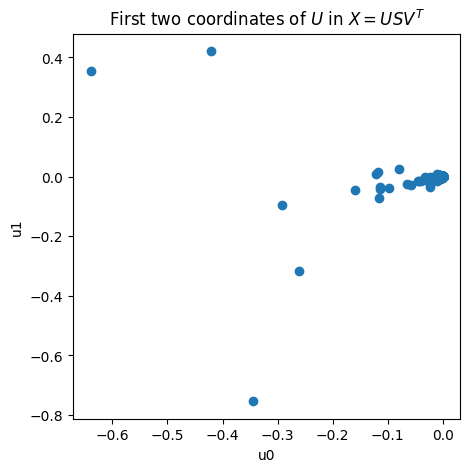

In [10]:
plt.figure(figsize=(5, 5))

plt.title(r'First two coordinates of $U$ in $X = USV^T$')
plt.scatter(U[:, 0], U[:, 1])
plt.xlabel('u0')
plt.ylabel('u1')

plt.show()

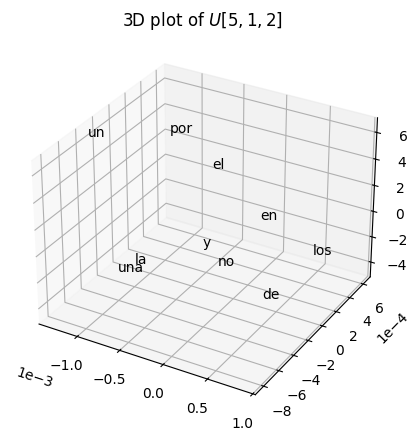

In [18]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": "3d"})

dim0, dim1, dim2 = 5, 1, 2

ax.set_title(fr'3D plot of $U[{dim0}, {dim1}, {dim2}]$')

ax.ticklabel_format(style='sci', scilimits=(0, 0))

for i, u in enumerate(U[5:15]):
    ax.plot(u[dim0], u[dim1], u[dim2])
    ax.text(u[dim0], u[dim1], u[dim2], words[i])

plt.show()

# GloVe

In [19]:
import torch
import torch.nn as nn

In [20]:
torch.set_default_dtype(torch.float64)

In [21]:
class GloVe:
    alpha = 0.75
    xmax = 100
    
    def __init__(self, X, enc_dim):
        self.X = torch.tensor(X)
        self.FX = torch.ones_like(self.X)
        self.FX[self.X < self.xmax] = (self.X[self.X < self.xmax] / self.xmax)**self.alpha
        self.LogX = torch.log(1 + self.X)

        N = X.shape[0]
        self.glove_center = torch.randn(N, enc_dim) / np.sqrt(N)
        self.glove_context = torch.randn(N, enc_dim) / np.sqrt(N)

        self.glove_context.requires_grad_()
        self.glove_center.requires_grad_()

        self.curr_iter = 0
        self.best_glove_center = None
        self.best_glove_context = None
        self.best_loss = float('infinity')

    def loss(self, w, v):
        return torch.sum(self.FX * (w @ v.T - self.LogX)**2)

    def best_embedding(self):
        return (self.best_glove_center + self.best_glove_context).detach()

    def train(self, n_iter, lr=0.01, max_lr=0.1, show=True):
        glove_opt = torch.optim.Adam([self.glove_center, self.glove_context], lr=lr)
        glove_scheduler = torch.optim.lr_scheduler.OneCycleLR(glove_opt, max_lr=max_lr, total_steps=n_iter)
        
        for n in range(n_iter):
            loss = self.loss(self.glove_center, self.glove_context)

            if show:
                print(f'iteration: {self.curr_iter + n:3d}, loss: {loss.item()}', end='\r')
            
            loss.backward()
            
            with torch.no_grad():
                if loss.item() < self.best_loss:
                    self.best_loss = loss.item()
                    self.best_glove_center = self.glove_center.detach().clone()
                    self.best_glove_context = self.glove_context.detach().clone()

                glove_opt.step()
                glove_scheduler.step()
                
                glove_opt.zero_grad()


        self.curr_iter += n_iter
        return self.best_embedding()

    def save(self, filename='glove.pt'):
        if self.best_loss is not None:
            torch.save({
                'center': self.best_glove_center,
                'context': self.best_glove_context,
                'loss': self.best_loss,
                'iteration': self.curr_iter,
            }, filename)

    def load(self, filename='glove.pt'):
        data = torch.load(filename)
        self.best_loss = data.get('loss')
        self.best_glove_center = data.get('center')
        self.best_glove_context = data.get('context')
        self.curr_iter = data.get('iteration')

In [25]:
enc_dim = 50
glove = GloVe(X, enc_dim)

In [26]:
Phi = glove.train(1_000, lr=0.01, max_lr=0.1)

iteration: 999, loss: 994.31894486225587

In [27]:
glove.save(f'Embeddings/{title} -- {enc_dim}.pt')

In [28]:
idx_padre, idx_madre = words.index('padre'), words.index('madre')
idx_hombre, idx_mujer = words.index('hombre'), words.index('mujer')

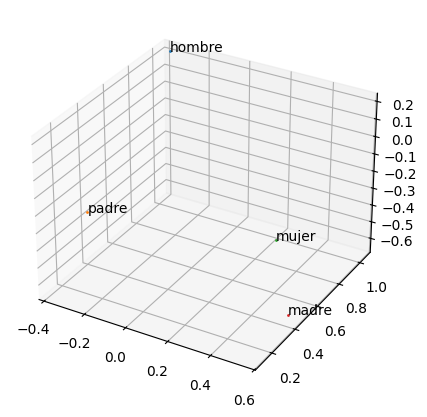

In [29]:
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': '3d'})

for idx in [idx_hombre, idx_padre, idx_mujer, idx_madre]:
    ax.plot(Phi[idx][0], Phi[idx][1], Phi[idx][2], 'o', markersize=1)
    ax.text(Phi[idx][0], Phi[idx][1], Phi[idx][2], words[idx])

plt.show()

In [ ]:
Phi_norm_squared = torch.linalg.norm(Phi, axis=1)**2

In [ ]:
plt.hist(Phi_norm_squared)
plt.show()

idx_max = torch.argmax(Phi_norm_squared)
print(words[idx_max])

In [ ]:
def knn(idx, k=1):
    ''' returns the k nearest neighbors of word idx '''
    return torch.argsort(Phi[idx] @ Phi[idx] + Phi_norm_squared - 2 * Phi[idx]@Phi.T)[:k+1]

In [ ]:
for idx in [idx_hombre, idx_padre, idx_mujer, idx_madre]:
    idx_knn = knn(idx, k=5)
    
    print(f'Closest to \'{words[idx]}\':', end=' ')
    for idx_ in idx_knn:
        print(f'\'{words[idx_]}\'', end=', ')
    print()

In [ ]:
(Phi[idx_hombre] - Phi[idx_mujer]) @ (Phi[idx_padre] - Phi[idx_madre])

In [ ]:
Phi[idx_hombre] @ Phi[idx_mujer], Phi[idx_padre] @ Phi[idx_madre]

# Poincare GloVe